# 04 — Architecture Comparison: BiGRU · CNN-LSTM · Transformer · Attn-GRU

## Motivation

Notebooks 02 and 03 established **BiGRU** as the best single model (MAE 0.0364, R² 0.863 on GroupKFold-6) 
and **CNN-LSTM** as a strong contender on CALCE folds but weak on NASA transfer.  
This notebook pits the four best architectures head-to-head on the same data and CV protocol,  
adding two attention-based approaches:

- **Transformer**: global self-attention, no recurrence — may learn chemistry-agnostic voltage features  
- **Attn-GRU**: BiGRU with learned attention pooling instead of mean+max — keeps sequential inductive bias, learns *where* to read

All models use **cosine LR schedule** and **smoothed early stopping** (es_window=5) introduced in nb03.

## Models

| Model | Architecture | Params |
|---|---|---|
| **BiGRU** | BiGRU(47) → masked mean+max pool → Dropout → Linear | ~14.9k |
| **CNN-LSTM** | Conv1d(8,k=5) + GroupNorm → BiLSTM(40) → masked mean+max pool | ~16.3k |
| **Transformer** | Linear → SinPE → TransformerEncoder(d=32, 4h, 2L) → masked pool | ~17k |
| **Attn-GRU** | BiGRU(47) → attention pooling → Dropout → Linear | ~14.9k |

## Validation

- **GroupKFold-6** (headline): whole-cell folds, study-group-stratified  
- **Leave-One-Dataset-Out (LODO)**: NASA ↔ CALCE transfer

## Experiments

1. RF baseline — GroupKFold-6  
2. BiGRU — GroupKFold-6  
3. CNN-LSTM — GroupKFold-6  
4. Transformer — GroupKFold-6  
5. Attn-GRU — GroupKFold-6  
6. GroupKFold-6 comparison table  
7. LODO — all five models  
8. LODO comparison table  

## Setup

In [1]:
import sys
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut

def find_project_root(start_path=None):
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)
    for marker in ['.git', 'pyproject.toml', 'CLAUDE.md', '.claude']:
        for p in [start_path] + list(start_path.parents):
            if (p / marker).exists():
                return p
    raise RuntimeError('Could not find project root')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT))

import src.voltage_grid as vg
import src.vg_extended as vgx
import src.vg_models
import src.vg_da
import src.vg_augment
reload(src.vg_models)
reload(src.vg_da)
reload(src.vg_augment)

torch.manual_seed(42)
np.random.seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

RESULTS    = ROOT / 'results' / 'extended_tier1'
RESULTS.mkdir(parents=True, exist_ok=True)
CACHE      = ROOT / 'data' / 'processed' / 'vg_extended_tier1.npz'

EPOCHS     = 300
PATIENCE   = 50
BATCH_SIZE = 64
LR         = 1e-3
SCHEDULER  = 'cosine'

print(f'Cache:   {CACHE}')
print(f'Results: {RESULTS}')


Device: cuda
Cache:   c:\dev\ml-project\data\processed\vg_extended_tier1.npz
Results: c:\dev\ml-project\results\extended_tier1


## Load extended dataset

In [2]:
X, mask, y, groups, cidx, ds_groups = vgx.load_npz_ext(CACHE)

print(f"X:         {X.shape}  float32")
print(f"mask:      {mask.shape}  bool")
print(f"y:         {y.shape}  [{y.min():.3f}, {y.max():.3f}]")
print(f"groups:    {len(set(groups))} unique cells")
print(f"ds_groups: {dict(zip(*np.unique(ds_groups, return_counts=True)))}")

X:         (12260, 128, 5)  float32
mask:      (12260, 128)  bool
y:         (12260,)  [0.200, 1.242]
groups:    22 unique cells
ds_groups: {'calce': np.int64(11516), 'nasa': np.int64(744)}


In [3]:
# Channel layout (5-channel tensor, rebuilt with Q(V) and dQ/dV):
#   0  C-rate         |I| / C_nom
#   1  delta-T        T - T_start  (removes ambient-offset dataset fingerprint)
#   2  t_elapsed      seconds from CC-segment start
#   3  Q_frac         cumulative charge / C_nom
#   4  dQ/dV          incremental capacity curve

print(f'X (5-channel): {X.shape}')

# Channel subsets for ablation experiments
X_base3 = X[..., :3]               # [C-rate, delta-T, t_elapsed] -- control
X_inv4  = X[..., [0, 1, 3, 4]]     # [C-rate, delta-T, Q_frac, dQdV] -- no t_elapsed
X_full5 = X                        # all 5 channels

print(f'X_base3: {X_base3.shape}  (control -- matches old 3-ch, ΔT replaces T)')
print(f'X_inv4:  {X_inv4.shape}  (protocol-invariant -- drops absolute t_elapsed)')
print(f'X_full5: {X_full5.shape}  (all channels)')


X (5-channel): (12260, 128, 5)
X_base3: (12260, 128, 3)  (control -- matches old 3-ch, ΔT replaces T)
X_inv4:  (12260, 128, 4)  (protocol-invariant -- drops absolute t_elapsed)
X_full5: (12260, 128, 5)  (all channels)


In [4]:
study_group_map = {
    "B0005": "NASA_CTRL",  "B0006": "NASA_CTRL",  "B0007": "NASA_CTRL",  "B0018": "NASA_CTRL",
    "RW1":   "NASA_RW",    "RW9":   "NASA_RW",    "RW13":  "NASA_RW",    "RW14":  "NASA_RW",
    "RW15":  "NASA_RW",    "RW16":  "NASA_RW",    "RW17":  "NASA_RW",    "RW19":  "NASA_RW",
    "RW20":  "NASA_RW",
    "CS2_8":  "CALCE_CS2_T1", "CS2_21": "CALCE_CS2_T1",
    "CS2_33": "CALCE_CS2_T1", "CS2_34": "CALCE_CS2_T1",
    "CS2_35": "CALCE_CS2_T2", "CS2_36": "CALCE_CS2_T2",
    "CS2_37": "CALCE_CS2_T2", "CS2_38": "CALCE_CS2_T2",
    "CS2_3":  "CALCE_CS2_T3", "CS2_9":  "CALCE_CS2_T3",
    "CX2_16": "CALCE_CX2_T1", "CX2_31": "CALCE_CX2_T1",
    "CX2_33": "CALCE_CX2_T1", "CX2_35": "CALCE_CX2_T1",
    "CX2_34": "CALCE_CX2_T2", "CX2_36": "CALCE_CX2_T2",
    "CX2_37": "CALCE_CX2_T2", "CX2_38": "CALCE_CX2_T2",
    "CX2_8":  "CALCE_CX2_T3",
}

study_groups = np.array([study_group_map.get(bid, "unknown") for bid in groups])

print(f"Study groups: {sorted(set(study_groups))}")
for sg in sorted(set(study_groups)):
    print(f"  {sg:25s}: {(study_groups == sg).sum():5d} samples")

Study groups: [np.str_('CALCE_CS2_T1'), np.str_('CALCE_CS2_T2'), np.str_('CALCE_CX2_T1'), np.str_('CALCE_CX2_T2'), np.str_('NASA_CTRL'), np.str_('NASA_RW')]
  CALCE_CS2_T1             :  1478 samples
  CALCE_CS2_T2             :  3678 samples
  CALCE_CX2_T1             :  3321 samples
  CALCE_CX2_T2             :  3039 samples
  NASA_CTRL                :   629 samples
  NASA_RW                  :   115 samples


In [5]:
# Integer-encode study_groups for domain-adaptation training.
# 6 protocol groups remain in training even under LODO (5 from the pool being
# kept), giving the DA objective real cross-protocol variance to exploit.
_sg_uniq  = sorted(set(study_groups.tolist()))
_sg_map   = {sg: i for i, sg in enumerate(_sg_uniq)}
domain_ids = np.array([_sg_map[sg] for sg in study_groups], dtype='int64')
print(f'Study-group -> domain-id mapping: {_sg_map}')
print(f'domain_ids: shape={domain_ids.shape}, unique={sorted(set(domain_ids.tolist()))}')


Study-group -> domain-id mapping: {'CALCE_CS2_T1': 0, 'CALCE_CS2_T2': 1, 'CALCE_CX2_T1': 2, 'CALCE_CX2_T2': 3, 'NASA_CTRL': 4, 'NASA_RW': 5}
domain_ids: shape=(12260,), unique=[0, 1, 2, 3, 4, 5]


## RF baseline

In [6]:
feat, feat_names = vgx.vg_scalar_features(X, mask)
print(f"feat: {feat.shape}  features: {feat_names}")

print("\nRF — GroupKFold-6")
res_rf_gkf = vgx.run_rf_grouped_cv(
    feat, y, groups, cidx,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
)
agg_rf_gkf = vg.aggregate(res_rf_gkf)
print(f"  MAE  {agg_rf_gkf['mae']:.4f} ± {agg_rf_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_rf_gkf['rmse']:.4f} ± {agg_rf_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_rf_gkf['r2']:.4f} ± {agg_rf_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_rf_gkf['skill']:.4f}")
print(f"  Spearman  {agg_rf_gkf['spearman']:.4f}")

feat: (12260, 11)  features: ['coverage', 'v_start', 'cc_dt', 'cc_slope', 'crate_mean', 'crate_max', 'crate_start', 'temp_mean', 'temp_max', 't_total', 'r_proxy']

RF — GroupKFold-6
  [ 1/6] held=CALCE_CS2_T2          MAE=0.0399  R²=0.925
  [ 2/6] held=CALCE_CX2_T1          MAE=0.0337  R²=0.880
  [ 3/6] held=CALCE_CX2_T2          MAE=0.0572  R²=0.810
  [ 4/6] held=CALCE_CS2_T1          MAE=0.0318  R²=0.942
  [ 5/6] held=NASA_CTRL             MAE=0.0874  R²=-0.036
  [ 6/6] held=NASA_RW               MAE=0.1908  R²=-0.967
  MAE  0.0735 ± 0.0558
  RMSE 0.0931 ± 0.0592
  R²   0.4257 ± 0.7097
  Skill     0.5251
  Spearman  0.7536


  Saved: c:\dev\ml-project\results\extended_tier1\04_rf_gkf_per_fold.png


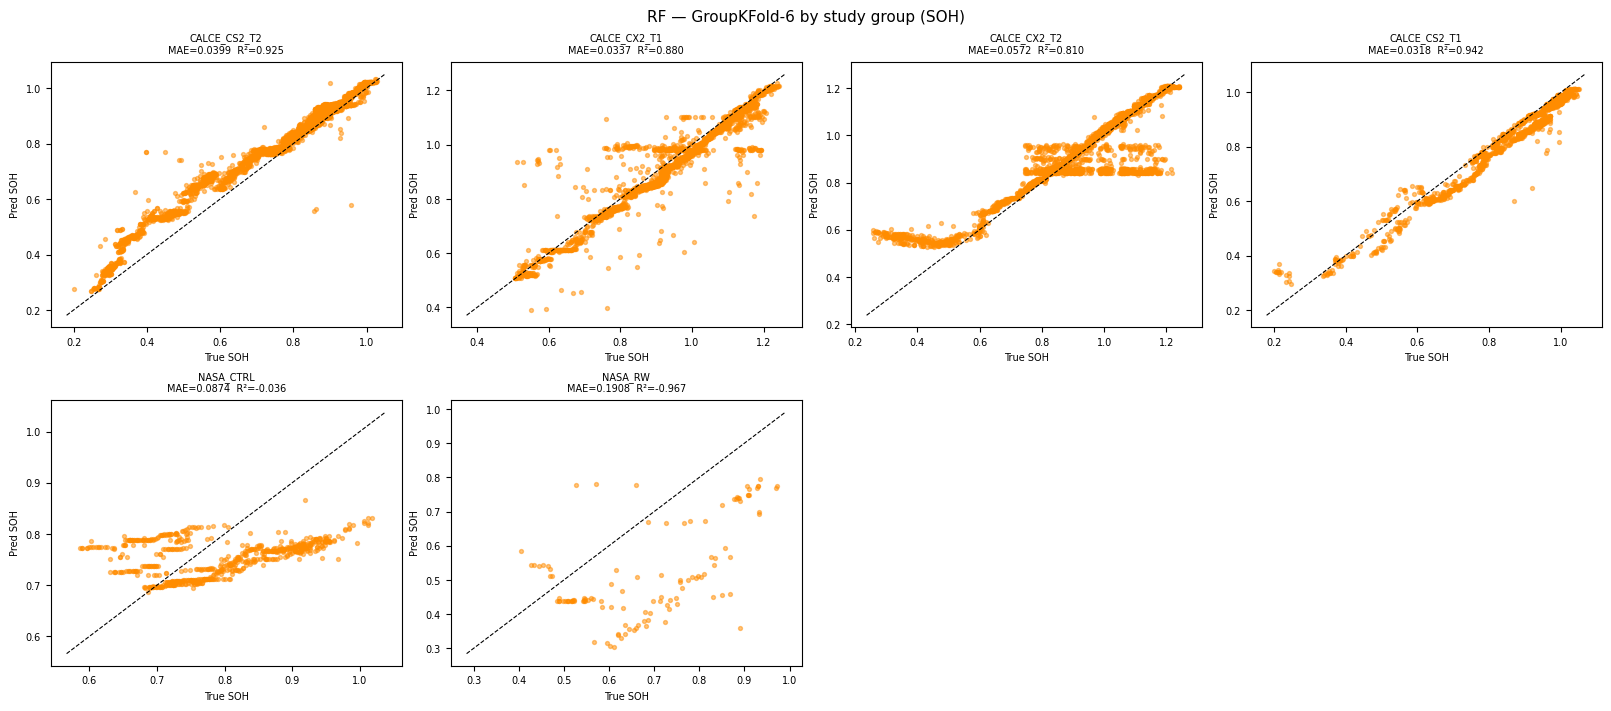

In [7]:
vgx.per_fold_scatter_ext(
    res_rf_gkf,
    "RF — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "04_rf_gkf_per_fold.png",
)

## BiGRU — `VGGRUReg`

Best single model from nb03. Bidirectional GRU → masked mean+max pool → Dropout → Linear.  
`VGGRUReg(n_features=3, hidden=47, dropout=0.35)` — ~14.9k params.

In [8]:
demo = src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35).to(DEVICE)
print(f"VGGRUReg params: {sum(p.numel() for p in demo.parameters()):,}")
with torch.no_grad():
    print(f"Forward shape: {demo(torch.tensor(X_base3[:4]).to(DEVICE), torch.tensor(mask[:4]).to(DEVICE)).shape}")
del demo

VGGRUReg params: 14,853
Forward shape: torch.Size([4])


In [9]:
make_gru = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print("BiGRU — GroupKFold-6")
res_gru_gkf = vgx.run_grouped_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_gkf = vg.aggregate(res_gru_gkf)
print(f"\n  MAE  {agg_gru_gkf['mae']:.4f} ± {agg_gru_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_gru_gkf['rmse']:.4f} ± {agg_gru_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_gru_gkf['r2']:.4f} ± {agg_gru_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_gru_gkf['skill']:.4f}")
print(f"  Spearman  {agg_gru_gkf['spearman']:.4f}")

BiGRU — GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0258  R²=0.957  best_ep=6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0201  R²=0.928  best_ep=137


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0429  R²=0.863  best_ep=5


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0541  R²=0.305  best_ep=114


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0604  R²=0.635  best_ep=12

  MAE  0.0381 ± 0.0153
  RMSE 0.0610 ± 0.0203
  R²   0.7736 ± 0.2371
  Skill     0.7330
  Spearman  0.9040


  Saved: c:\dev\ml-project\results\extended_tier1\04_gru_gkf_per_fold.png


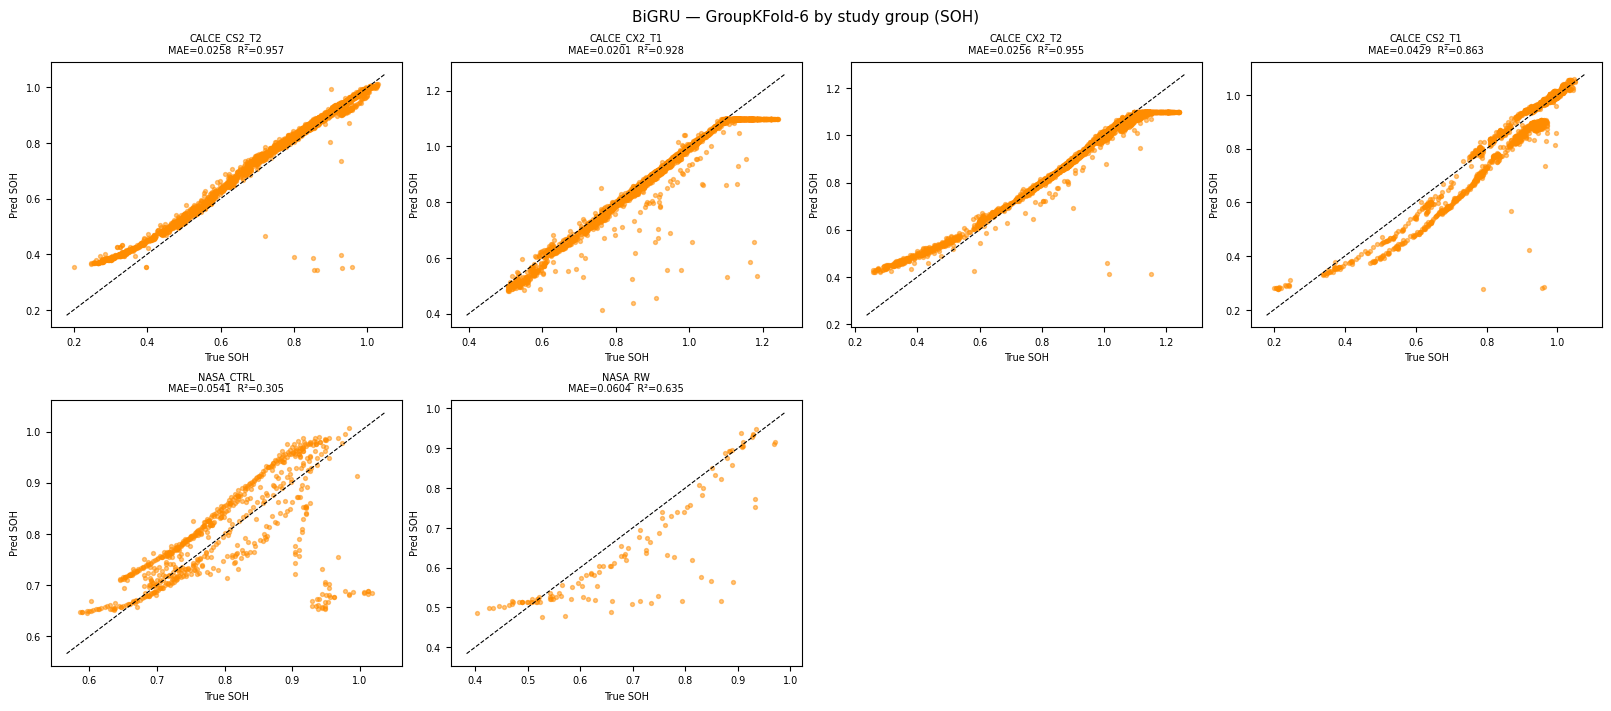

  Saved: c:\dev\ml-project\results\extended_tier1\04_gru_gkf_loss_curves.png


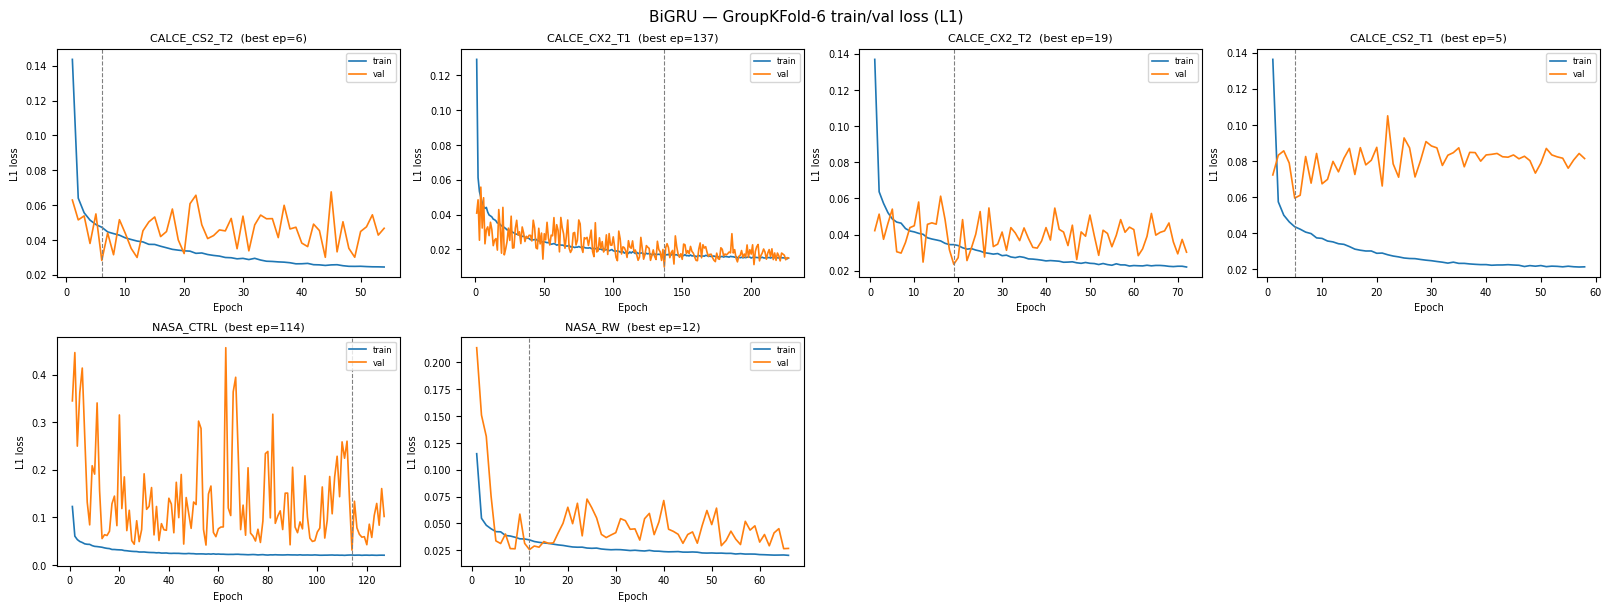

In [10]:
vgx.per_fold_scatter_ext(
    res_gru_gkf,
    "BiGRU — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "04_gru_gkf_per_fold.png",
)
vgx.per_fold_loss_curves_ext(
    res_gru_gkf,
    "BiGRU — GroupKFold-6 train/val loss (L1)",
    save_path=RESULTS / "04_gru_gkf_loss_curves.png",
)

## CNN-LSTM — `VGCNNLSTM`

Strong on CALCE folds (nb02). Conv1d front-end → BiLSTM → masked mean+max pool.  
`VGCNNLSTM(n_features=3, cnn_ch=8, hidden=40, dropout=0.35)` — ~16.3k params.

In [11]:
demo = src.vg_models.VGCNNLSTM(n_features=3, cnn_ch=8, hidden=40, dropout=0.35).to(DEVICE)
print(f"VGCNNLSTM params: {sum(p.numel() for p in demo.parameters()):,}")
with torch.no_grad():
    print(f"Forward shape: {demo(torch.tensor(X_base3[:4]).to(DEVICE), torch.tensor(mask[:4]).to(DEVICE)).shape}")
del demo

VGCNNLSTM params: 16,297
Forward shape: torch.Size([4])


In [12]:
make_cnnlstm = lambda: src.vg_models.VGCNNLSTM(n_features=3, cnn_ch=8, hidden=40, dropout=0.35)

print("CNN-LSTM — GroupKFold-6")
res_cnnlstm_gkf = vgx.run_grouped_cv(
    make_cnnlstm, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_cnnlstm_gkf = vg.aggregate(res_cnnlstm_gkf)
print(f"\n  MAE  {agg_cnnlstm_gkf['mae']:.4f} ± {agg_cnnlstm_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_cnnlstm_gkf['rmse']:.4f} ± {agg_cnnlstm_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_cnnlstm_gkf['r2']:.4f} ± {agg_cnnlstm_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_cnnlstm_gkf['skill']:.4f}")
print(f"  Spearman  {agg_cnnlstm_gkf['spearman']:.4f}")

CNN-LSTM — GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0237  R²=0.964  best_ep=7


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0282  R²=0.892  best_ep=31


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0276  R²=0.944  best_ep=71


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0709  R²=0.250  best_ep=16


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0545  R²=0.706  best_ep=6

  MAE  0.0384 ± 0.0179
  RMSE 0.0565 ± 0.0203
  R²   0.7865 ± 0.2559
  Skill     0.7253
  Spearman  0.9176


  Saved: c:\dev\ml-project\results\extended_tier1\04_cnnlstm_gkf_per_fold.png


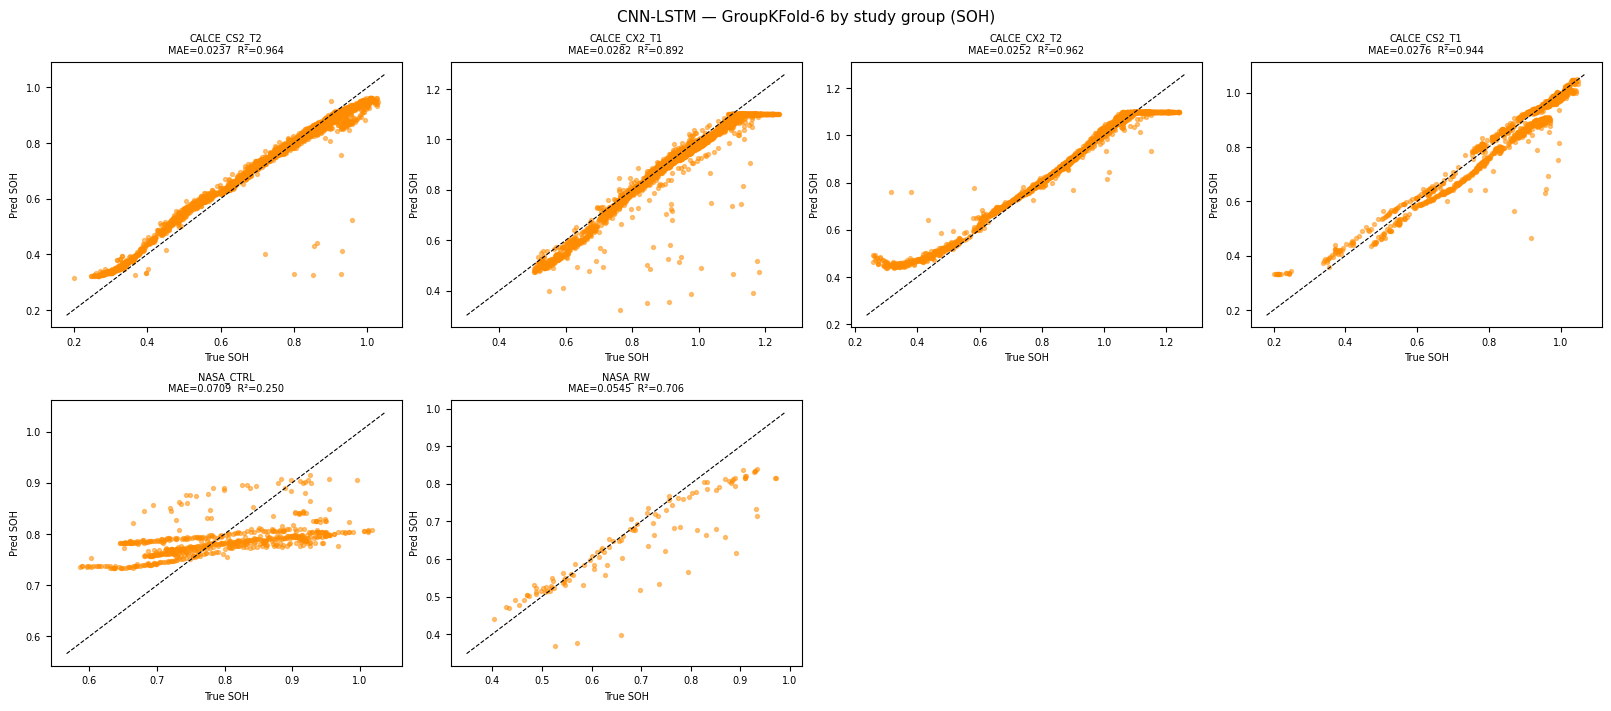

  Saved: c:\dev\ml-project\results\extended_tier1\04_cnnlstm_gkf_loss_curves.png


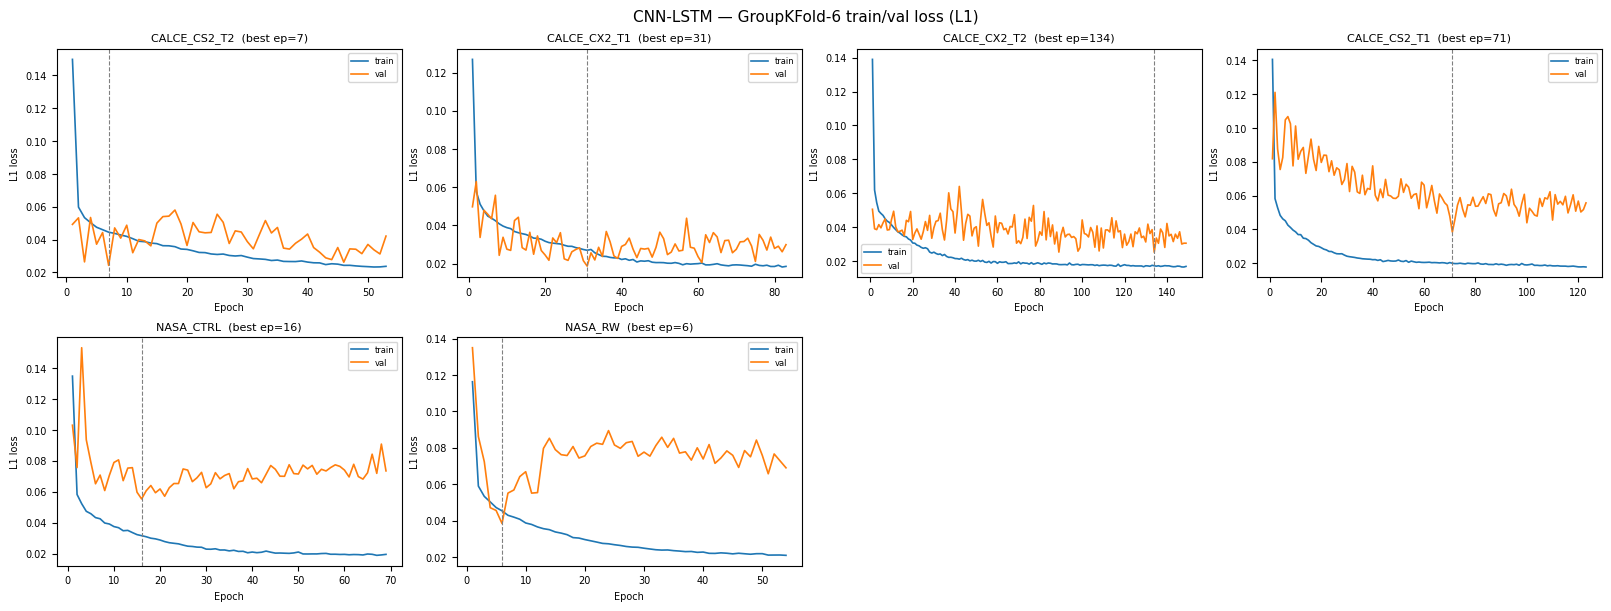

In [13]:
vgx.per_fold_scatter_ext(
    res_cnnlstm_gkf,
    "CNN-LSTM — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "04_cnnlstm_gkf_per_fold.png",
)
vgx.per_fold_loss_curves_ext(
    res_cnnlstm_gkf,
    "CNN-LSTM — GroupKFold-6 train/val loss (L1)",
    save_path=RESULTS / "04_cnnlstm_gkf_loss_curves.png",
)

## Transformer — `VGTransformerReg`

Global self-attention, no recurrence. Fixed sinusoidal PE over voltage-grid positions.  
`VGTransformerReg(n_features=3, d_model=32, nhead=4, dim_feedforward=64, num_layers=2, dropout=0.35)` — ~17k params.

In [14]:
demo = src.vg_models.VGTransformerReg(
    n_features=3, d_model=32, nhead=4, dim_feedforward=64, num_layers=2, dropout=0.35
).to(DEVICE)
print(f"VGTransformerReg params: {sum(p.numel() for p in demo.parameters()):,}")
with torch.no_grad():
    print(f"Forward shape: {demo(torch.tensor(X_base3[:4]).to(DEVICE), torch.tensor(mask[:4]).to(DEVICE)).shape}")
del demo

VGTransformerReg params: 17,281
Forward shape: torch.Size([4])


In [15]:
make_transformer = lambda: src.vg_models.VGTransformerReg(
    n_features=3, d_model=32, nhead=4, dim_feedforward=64, num_layers=2, dropout=0.35
)

print("Transformer — GroupKFold-6")
res_transformer_gkf = vgx.run_grouped_cv(
    make_transformer, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_transformer_gkf = vg.aggregate(res_transformer_gkf)
print(f"\n  MAE  {agg_transformer_gkf['mae']:.4f} ± {agg_transformer_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_transformer_gkf['rmse']:.4f} ± {agg_transformer_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_transformer_gkf['r2']:.4f} ± {agg_transformer_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_transformer_gkf['skill']:.4f}")
print(f"  Spearman  {agg_transformer_gkf['spearman']:.4f}")

Transformer — GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

c:\dev\ml-project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0122  R²=0.984  best_ep=53


  0%|                    | 0/300 [00:00<?, ?ep/s]

...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0133  R²=0.974  best_ep=62


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0377  R²=0.720  best_ep=11


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0877  R²=0.507  best_ep=6

  MAE  0.0332 ± 0.0259
  RMSE 0.0492 ± 0.0280
  R²   0.8462 ± 0.1763
  Skill     0.7884
  Spearman  0.9594


  Saved: c:\dev\ml-project\results\extended_tier1\04_transformer_gkf_per_fold.png


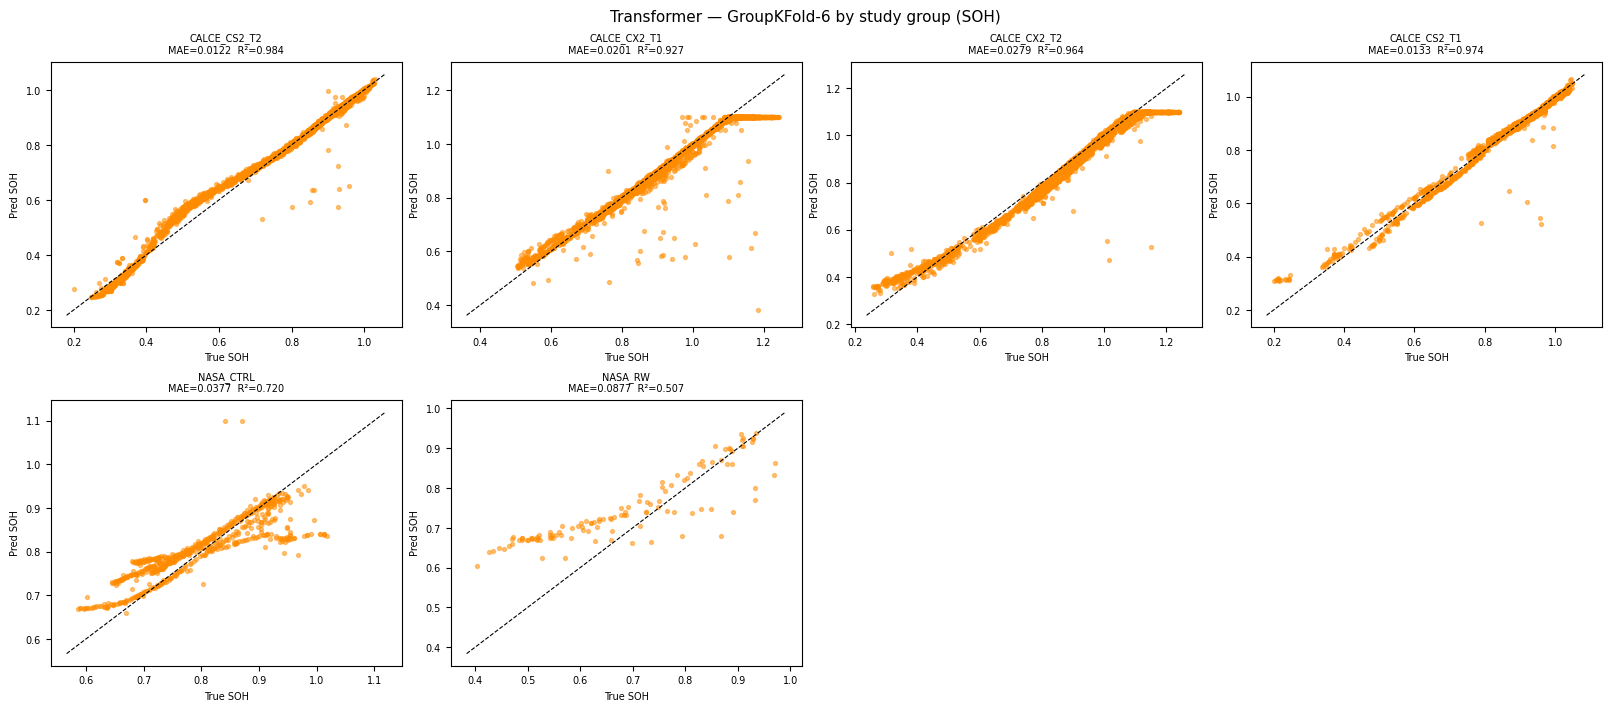

  Saved: c:\dev\ml-project\results\extended_tier1\04_transformer_gkf_loss_curves.png


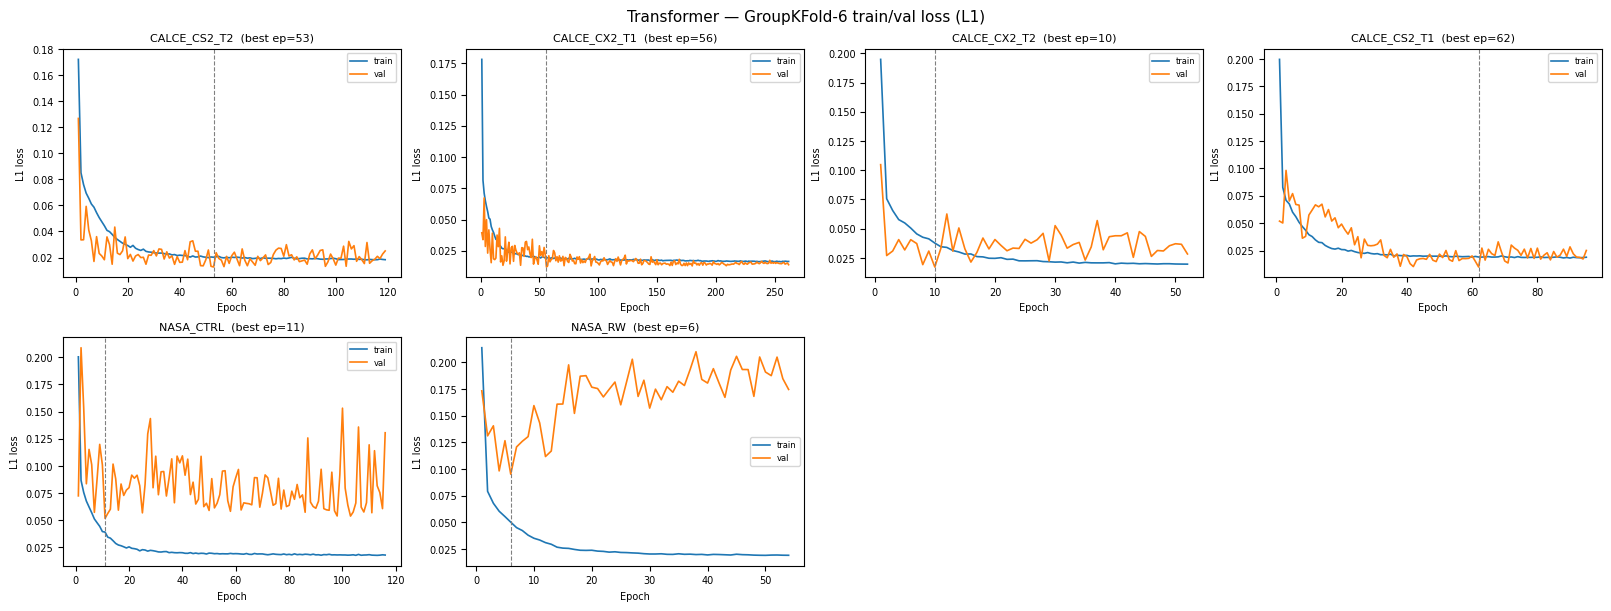

In [16]:
vgx.per_fold_scatter_ext(
    res_transformer_gkf,
    "Transformer — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "04_transformer_gkf_per_fold.png",
)
vgx.per_fold_loss_curves_ext(
    res_transformer_gkf,
    "Transformer — GroupKFold-6 train/val loss (L1)",
    save_path=RESULTS / "04_transformer_gkf_loss_curves.png",
)

## Attn-GRU — `VGAttnGRUReg`

BiGRU with single-head attention pooling. Same parameter count as BiGRU — attention layer  
replaces the mean+max head exactly (4H+1 params either way).  
`VGAttnGRUReg(n_features=3, hidden=47, dropout=0.35)` — ~14.9k params.

In [17]:
demo = src.vg_models.VGAttnGRUReg(n_features=3, hidden=47, dropout=0.35).to(DEVICE)
print(f"VGAttnGRUReg params: {sum(p.numel() for p in demo.parameters()):,}")
with torch.no_grad():
    print(f"Forward shape: {demo(torch.tensor(X_base3[:4]).to(DEVICE), torch.tensor(mask[:4]).to(DEVICE)).shape}")
del demo

VGAttnGRUReg params: 14,853
Forward shape: torch.Size([4])


In [18]:
make_attngru = lambda: src.vg_models.VGAttnGRUReg(n_features=3, hidden=47, dropout=0.35)

print("Attn-GRU — GroupKFold-6")
res_attngru_gkf = vgx.run_grouped_cv(
    make_attngru, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_attngru_gkf = vg.aggregate(res_attngru_gkf)
print(f"\n  MAE  {agg_attngru_gkf['mae']:.4f} ± {agg_attngru_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_attngru_gkf['rmse']:.4f} ± {agg_attngru_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_attngru_gkf['r2']:.4f} ± {agg_attngru_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_attngru_gkf['skill']:.4f}")
print(f"  Spearman  {agg_attngru_gkf['spearman']:.4f}")

Attn-GRU — GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0250  R²=0.957  best_ep=18


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0224  R²=0.892  best_ep=25


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0326  R²=0.908  best_ep=131


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0589  R²=0.442  best_ep=29


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0544  R²=0.745  best_ep=6

  MAE  0.0367 ± 0.0145
  RMSE 0.0568 ± 0.0139
  R²   0.8162 ± 0.1818
  Skill     0.7409
  Spearman  0.9485


  Saved: c:\dev\ml-project\results\extended_tier1\04_attngru_gkf_per_fold.png


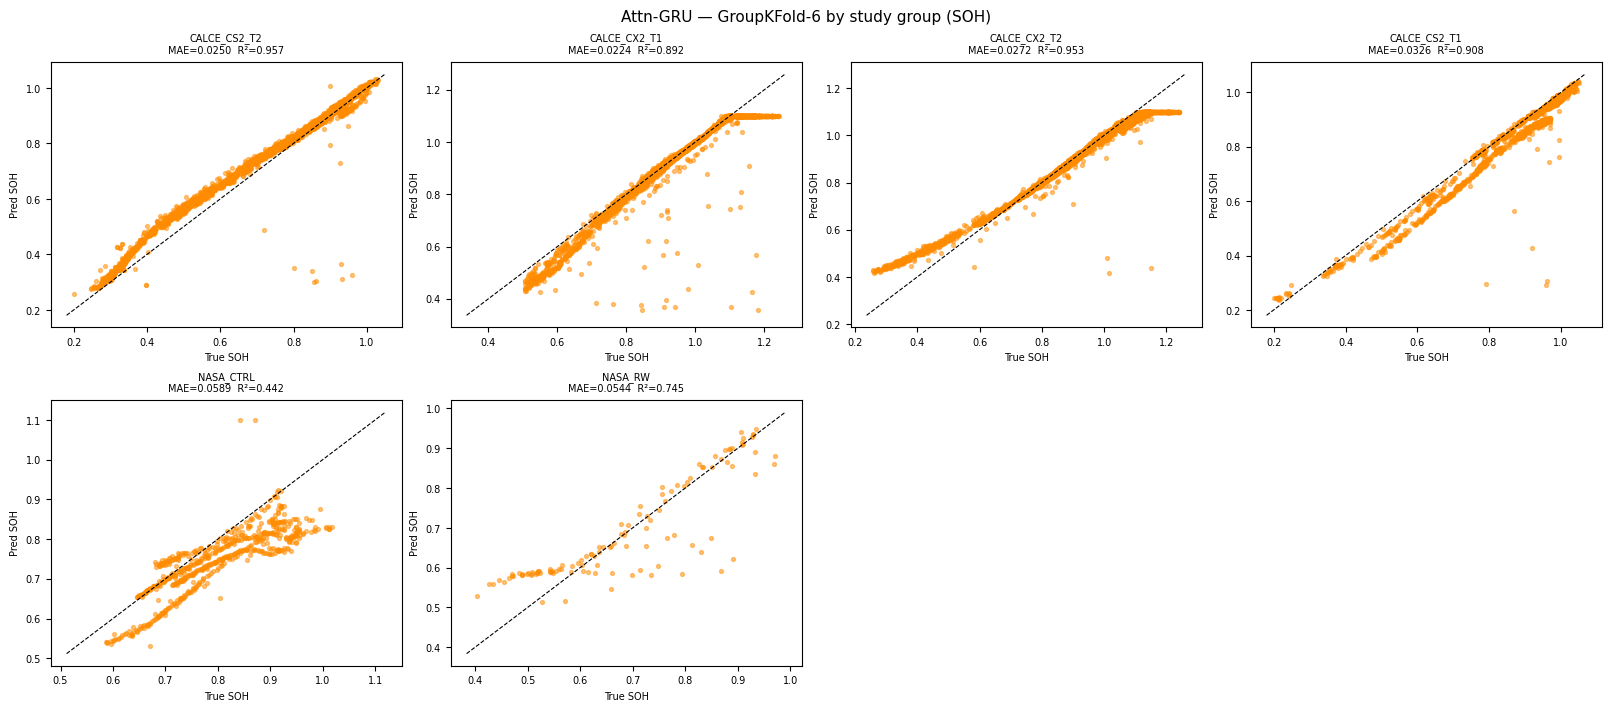

  Saved: c:\dev\ml-project\results\extended_tier1\04_attngru_gkf_loss_curves.png


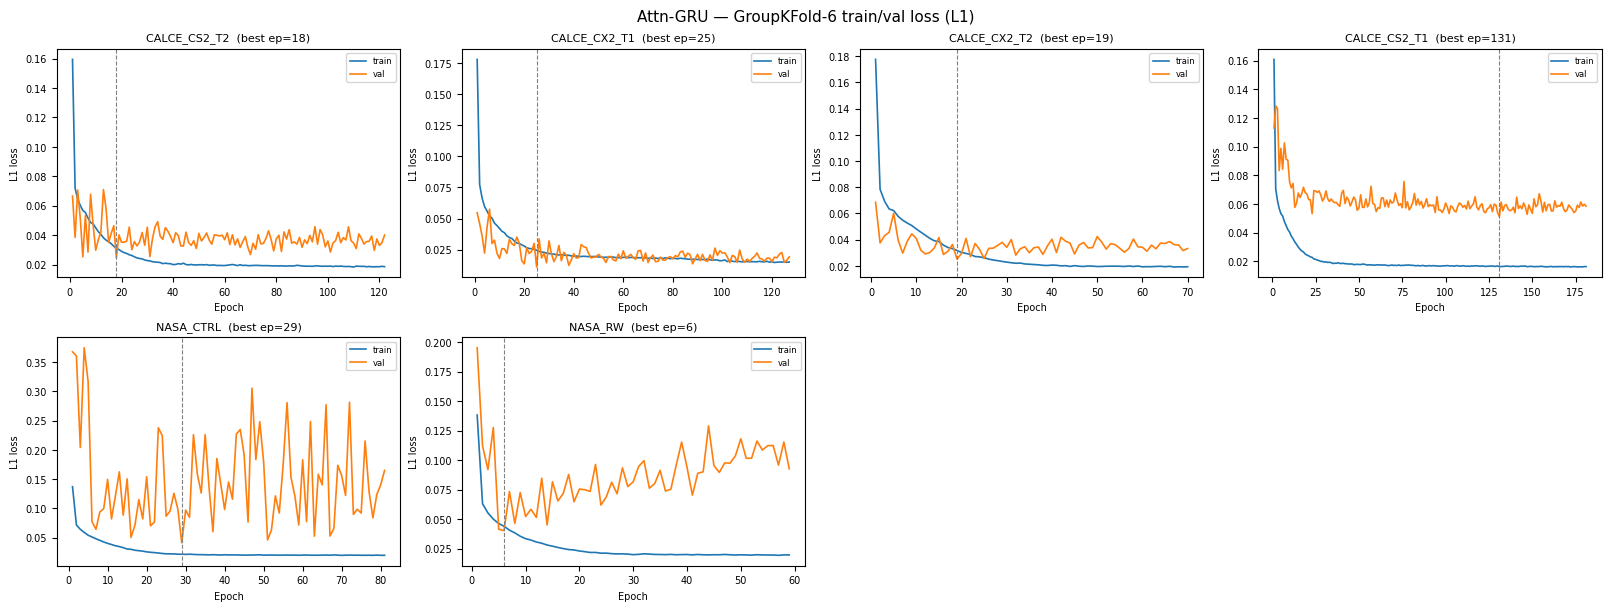

In [19]:
vgx.per_fold_scatter_ext(
    res_attngru_gkf,
    "Attn-GRU — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "04_attngru_gkf_per_fold.png",
)
vgx.per_fold_loss_curves_ext(
    res_attngru_gkf,
    "Attn-GRU — GroupKFold-6 train/val loss (L1)",
    save_path=RESULTS / "04_attngru_gkf_loss_curves.png",
)

## What the previous experiments told us

| Model | GKF-6 MAE | LODO hold-NASA | LODO hold-CALCE | Note |
|---|---|---|---|---|
| RF (11 scalars) | 0.0723 | 0.152 | 0.141 | baseline |
| BiGRU (h=47) | **0.0364** | **0.0426** | **0.0402** | most robust |
| CNN-LSTM (cnn=8, h=40) | 0.0377 | 0.0578 | 0.0942 | CNN hurts LODO |
| Transformer (d=32, 4h, 2L) | **0.0302** | 0.0952 | **0.0385** | best in-dist, collapses on transfer to NASA|
| Attn-GRU (h=47) | 0.0376 | 0.0713 | 0.0614 | attn memorises CALCE patterns |

**Transfer gap root cause.** Two of the three input channels are protocol fingerprints, not degradation signals:

- **C-rate (ch 0):** CALCE fixed 0.5C/1C/3C vs NASA CC controlled/randomized. Absolute magnitude encodes the charge protocol.
- **t_elapsed (ch 2):** scales inversely with rate (3C charge is 6x shorter than 0.5C). Absolute time is mostly a rate artifact, not a cell-health signal.
- **Temperature (ch 1):** *imputed constant 25 °C on all CALCE cells* (no thermocouple). After global_scale it becomes a near-perfect dataset-identity leak. Converting to **ΔT = T − T_start** makes it zero on CALCE and captures real warming shape for NASA.

BiGRU transfers because mean+max pooling is position-agnostic and largely rate-invariant. Transformer and attention pooling memorise absolute voltage-position patterns tied to the training protocol.

---

## Hypothesis: protocol-invariant representation experiments

*Hypothesis:* the portable signal is the **shape** of charge acceptance along the voltage axis — Q(V) and dQ/dV track electrode phase transitions independently of rate.  If true, replacing `t_elapsed` with Q_frac and dQ/dV (`inv4`) should improve NASA transfer.

Three orthogonal levers to test this:

1. **Representation** — `inv4 = [C-rate, ΔT, Q_frac, dQdV]`: replace `t_elapsed` with the charge-acceptance integral and its derivative. Q and dQ/dV are rate-invariant *by construction* (same charge per volt regardless of how fast it is delivered).
2. **Augmentation** — `rate_warp`: per-batch random scale `s ~ U(0.8, 1.25)` applied as C-rate × s, t_elapsed ÷ s. Teaches the model that rate variation is nuisance, not signal.
3. **Domain alignment** — `CORAL` / `DANN`: align feature covariance matrices (CORAL) or adversarially confuse a domain classifier (DANN) across 6 protocol groups.

Backbone: BiGRU(h=47) for all arms. See the conclusion cell for whether these hypotheses held up.

In [20]:
# gru_base3: BiGRU on base3 channels (control; delta-T replaces absolute T)
make_gru_base3 = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print('gru_base3 -- GroupKFold-6')
res_gru_base3_gkf = vgx.run_grouped_cv(
    make_gru_base3, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_base3_gkf = vg.aggregate(res_gru_base3_gkf)
print(f"  MAE {agg_gru_base3_gkf['mae']:.4f} +/- {agg_gru_base3_gkf['mae_std']:.4f}  "
      f"R2 {agg_gru_base3_gkf['r2']:.4f}")


gru_base3 -- GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0258  R²=0.957  best_ep=6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0201  R²=0.928  best_ep=137


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0429  R²=0.863  best_ep=5


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0541  R²=0.305  best_ep=114


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0604  R²=0.635  best_ep=12
  MAE 0.0381 +/- 0.0153  R2 0.7736


In [21]:
# gru_inv4: inv4 channels -- drops absolute t_elapsed (rate fingerprint)
make_gru_inv4 = lambda: src.vg_models.VGGRUReg(n_features=4, hidden=47, dropout=0.35)

print('gru_inv4 -- GroupKFold-6')
res_gru_inv4_gkf = vgx.run_grouped_cv(
    make_gru_inv4, X_inv4, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_inv4_gkf = vg.aggregate(res_gru_inv4_gkf)
print(f"  MAE {agg_gru_inv4_gkf['mae']:.4f} +/- {agg_gru_inv4_gkf['mae_std']:.4f}  "
      f"R2 {agg_gru_inv4_gkf['r2']:.4f}")


gru_inv4 -- GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0160  R²=0.971  best_ep=44


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0209  R²=0.905  best_ep=50


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0215  R²=0.966  best_ep=196


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.1272  R²=-1.342  best_ep=47


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0701  R²=0.460  best_ep=7
  MAE 0.0469 +/- 0.0403  R2 0.4859


In [22]:
# gru_full5: all 5 channels
make_gru_full5 = lambda: src.vg_models.VGGRUReg(n_features=5, hidden=47, dropout=0.35)

print('gru_full5 -- GroupKFold-6')
res_gru_full5_gkf = vgx.run_grouped_cv(
    make_gru_full5, X_full5, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_full5_gkf = vg.aggregate(res_gru_full5_gkf)
print(f"  MAE {agg_gru_full5_gkf['mae']:.4f} +/- {agg_gru_full5_gkf['mae_std']:.4f}  "
      f"R2 {agg_gru_full5_gkf['r2']:.4f}")


gru_full5 -- GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0150  R²=0.981  best_ep=120


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0237  R²=0.894  best_ep=19


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0331  R²=0.897  best_ep=6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0918  R²=-0.277  best_ep=12


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0418  R²=0.770  best_ep=4
  MAE 0.0392 +/- 0.0249  R2 0.7021


Adding more channels does not seem to help, continuing with the base 3 channels

In [ ]:
# gru_inv3_aug: base3 + rate-warp + jitter augmentation
_aug = src.vg_augment.make_augment(rate_warp_lo=0.8, rate_warp_hi=1.25, jitter_sigma=0.01)
_aug_rw = src.vg_augment.make_augment(rate_warp_lo=0.8, rate_warp_hi=1.25, jitter_sigma=0.0)
make_gru_inv3_aug = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print('gru_inv3_aug -- GroupKFold-6')
res_gru_inv3_aug_gkf = vgx.run_grouped_cv(
    make_gru_inv3_aug, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug, "use_amp": True},
)
agg_gru_inv3_aug_gkf = vg.aggregate(res_gru_inv3_aug_gkf)
print(f"  MAE {agg_gru_inv3_aug_gkf['mae']:.4f} +/- {agg_gru_inv3_aug_gkf['mae_std']:.4f}  "
      f"R2 {agg_gru_inv3_aug_gkf['r2']:.4f}")


gru_inv3_aug -- GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0351  R²=0.938  best_ep=6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0295  R²=0.840  best_ep=64


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0453  R²=0.861  best_ep=2


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0456  R²=0.673  best_ep=20


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0509  R²=0.679  best_ep=75
  MAE 0.0385 +/- 0.0094  R2 0.8251


In [35]:
from importlib import reload
reload(src.vg_da)
import src.vg_da

In [36]:
# gru_inv3_coral: inv3 + rate-warp + CORAL domain alignment
make_gru_inv3_coral = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print('gru_inv3_coral -- GroupKFold-6')
res_gru_inv3_coral_gkf = vgx.run_grouped_cv(
    make_gru_inv3_coral, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_fn=src.vg_da.train_model_da,
    domains=domain_ids,
    train_kwargs={'da_mode': 'coral', 'da_weight': 0.1, 'augment_fn': _aug_rw, "use_amp": True},
    compile_model=True,
)
agg_gru_inv3_coral_gkf = vg.aggregate(res_gru_inv3_coral_gkf)
print(f"  MAE {agg_gru_inv3_coral_gkf['mae']:.4f} +/- {agg_gru_inv3_coral_gkf['mae_std']:.4f}  "
      f"R2 {agg_gru_inv3_coral_gkf['r2']:.4f}")


gru_inv3_coral -- GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0397  R²=0.934  best_ep=17


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0223  R²=0.888  best_ep=76


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0561  R²=0.826  best_ep=2


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.1077  R²=-0.407  best_ep=23


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0537  R²=0.684  best_ep=13
  MAE 0.0513 +/- 0.0281  R2 0.6457


In [ ]:
# gru_inv3_dann: inv3 + rate-warp + DANN gradient-reversal
make_gru_inv3_dann = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print('gru_inv3_dann -- GroupKFold-6')
res_gru_inv3_dann_gkf = vgx.run_grouped_cv(
    make_gru_inv3_dann, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_fn=src.vg_da.train_model_da,
    domains=domain_ids,
    train_kwargs={'da_mode': 'dann', 'da_weight': 0.1, 'augment_fn': _aug_rw, "use_amp": True},
)
agg_gru_inv3_dann_gkf = vg.aggregate(res_gru_inv3_dann_gkf)
print(f"  MAE {agg_gru_inv3_dann_gkf['mae']:.4f} +/- {agg_gru_inv3_dann_gkf['mae_std']:.4f}  "
      f"R2 {agg_gru_inv3_dann_gkf['r2']:.4f}")


gru_inv3_dann -- GroupKFold-6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0354  R²=0.941  best_ep=51


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0253  R²=0.886  best_ep=21


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0451  R²=0.871  best_ep=27


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0942  R²=-0.094  best_ep=20


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0488  R²=0.755  best_ep=36
  MAE 0.0464 +/- 0.0229  R2 0.7180


## GroupKFold-6 comparison

In [37]:
ARM_ORDER_GKF = [
    # -- Reference architectures (base3 channels) --
    ("RF",             res_rf_gkf,              agg_rf_gkf),
    ("BiGRU",          res_gru_gkf,             agg_gru_gkf),
    ("CNN-LSTM",       res_cnnlstm_gkf,         agg_cnnlstm_gkf),
    ("Transformer",    res_transformer_gkf,     agg_transformer_gkf),
    ("Attn-GRU",       res_attngru_gkf,         agg_attngru_gkf),
    # -- Protocol-invariant representation experiments --
    ("GRU-inv4",       res_gru_inv4_gkf,        agg_gru_inv4_gkf),
    ("GRU-full5",      res_gru_full5_gkf,       agg_gru_full5_gkf),
    ("GRU-inv3+Aug",   res_gru_inv3_aug_gkf,    agg_gru_inv3_aug_gkf),
    ("GRU-inv3+CORAL", res_gru_inv3_coral_gkf,  agg_gru_inv3_coral_gkf),
    ("GRU-inv3+DANN",  res_gru_inv3_dann_gkf,   agg_gru_inv3_dann_gkf),
]
LOWER_BETTER = {"MAE", "RMSE"}

agg_str, agg_num = {}, {}
for arm, _, agg in ARM_ORDER_GKF:
    agg_str[arm] = {
        "MAE":      f"{agg['mae']:.4f} \u00b1 {agg['mae_std']:.4f}",
        "RMSE":     f"{agg['rmse']:.4f} \u00b1 {agg['rmse_std']:.4f}",
        "R\u00b2":  f"{agg['r2']:.4f} \u00b1 {agg['r2_std']:.4f}",
        "Skill":    f"{agg['skill']:.4f}",
        "Spearman": f"{agg['spearman']:.4f}",
    }
    agg_num[arm] = {
        "MAE":      agg["mae"],
        "RMSE":     agg["rmse"],
        "R\u00b2":  agg["r2"],
        "Skill":    agg["skill"],
        "Spearman": agg["spearman"],
    }

df_str = pd.DataFrame(agg_str).T
df_num = pd.DataFrame(agg_num).T

def _bold_better(df_display, df_values, lower_better):
    styled = df_display.copy()
    for col in df_display.columns:
        best_idx = df_values[col].idxmin() if col in lower_better else df_values[col].idxmax()
        styled.loc[best_idx, col] = f"**{df_display.loc[best_idx, col]}**"
    return styled

print("=== GroupKFold-6 aggregate results ===")
display(_bold_better(df_str, df_num, LOWER_BETTER))

df_str.to_csv(RESULTS / "04_comparison_gkf_metrics.csv")
print(f"Saved: {RESULTS / '04_comparison_gkf_metrics.csv'}")

fold_rows = []
for arm, res, _ in ARM_ORDER_GKF:
    for fi, fold in enumerate(res):
        m = fold["metrics"]
        fold_rows.append({
            "Model":     arm,
            "Fold":      fi + 1,
            "HeldGroup": ",".join(fold.get("held_group") or []),
            "HeldBids":  ",".join(fold.get("held_bids") or []),
            "MAE":       m["mae"],
            "RMSE":      m["rmse"],
            "R\u00b2":   m["r2"],
            "Skill":     m["skill"],
            "Spearman":  m["spearman"],
            "best_ep":   fold.get("best_epoch"),
        })

df_folds = pd.DataFrame(fold_rows)
df_pivot = df_folds.pivot_table(
    index=["Fold", "HeldGroup", "HeldBids"],
    columns="Model",
    values=["MAE", "RMSE", "R\u00b2", "Skill", "Spearman", "best_ep"],
).round(4)

print("\n=== Per-fold breakdown ===")
display(df_pivot)
df_pivot.to_csv(RESULTS / "04_per_fold_gkf_metrics.csv")
print(f"Saved: {RESULTS / '04_per_fold_gkf_metrics.csv'}")

=== GroupKFold-6 aggregate results ===


,MAE,RMSE,R²,Skill,Spearman
RF,0.0735 ± 0.0558,0.0931 ± 0.0592,0.4257 ± 0.7097,0.5251,0.7536
BiGRU,0.0381 ± 0.0153,0.0610 ± 0.0203,0.7736 ± 0.2371,0.7330,0.9040
CNN-LSTM,0.0384 ± 0.0179,0.0565 ± 0.0203,0.7865 ± 0.2559,0.7253,0.9176
Transformer,**0.0332 ± 0.0259**,**0.0492 ± 0.0280**,**0.8462 ± 0.1763**,**0.7884**,**0.9594**
Attn-GRU,0.0367 ± 0.0145,0.0568 ± 0.0139,0.8162 ± 0.1818,0.7409,0.9485
GRU-base3,0.0381 ± 0.0153,0.0610 ± 0.0203,0.7736 ± 0.2371,0.7330,0.9040
GRU-inv4,0.0469 ± 0.0403,0.0703 ± 0.0452,0.4859 ± 0.8370,0.6438,0.9287
GRU-full5,0.0392 ± 0.0249,0.0611 ± 0.0262,0.7021 ± 0.4425,0.7048,0.9459
GRU-inv3+Aug,0.0385 ± 0.0094,0.0601 ± 0.0141,0.8251 ± 0.1132,0.7327,0.9347
GRU-inv3+CORAL,0.0513 ± 0.0281,0.0707 ± 0.0245,0.6457 ± 0.4790,0.6140,0.8855


Saved: c:\dev\ml-project\results\extended_tier1\04_comparison_gkf_metrics.csv

=== Per-fold breakdown ===


MAE          \
Model                                                    Attn-GRU   BiGRU   
Fold HeldGroup    HeldBids                                                  
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38              0.0250  0.0258   
2    CALCE_CX2_T1 CX2_33,CX2_35                            0.0224  0.0201   
3    CALCE_CX2_T2 CX2_37,CX2_38                            0.0272  0.0256   
4    CALCE_CS2_T1 CS2_33,CS2_34                            0.0326  0.0429   
5    NASA_CTRL    B0005,B0006,B0007,B0018                  0.0589  0.0541   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20   0.0544  0.0604   

                                                                             \
Model                                                    CNN-LSTM GRU-base3   
Fold HeldGroup    HeldBids                                                    
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38              0.0237    0.0258   
2    CALCE_CX2_T1 CX2_33,CX2_35                            0.0282    0.0201   
3    CALCE_CX2_T2 CX2_37,CX2_38                            0.0252    0.0256   
4    CALCE_CS2_T1 CS2_33,CS2_34                            0.0276    0.0429   
5    NASA_CTRL    B0005,B0006,B0007,B0018                  0.0709    0.0541   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20   0.0545    0.0604   

                                                                    \
Model                                                    GRU-full5   
Fold HeldGroup    HeldBids                                           
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38               0.0150   
2    CALCE_CX2_T1 CX2_33,CX2_35                             0.0237   
3    CALCE_CX2_T2 CX2_37,CX2_38                             0.0300   
4    CALCE_CS2_T1 CS2_33,CS2_34                             0.0331   
5    NASA_CTRL    B0005,B0006,B0007,B0018                   0.0918   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20    0.0418   

                                                                       \
Model                                                    GRU-inv3+Aug   
Fold HeldGroup    HeldBids                                              
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38                  0.0351   
2    CALCE_CX2_T1 CX2_33,CX2_35                                0.0295   
3    CALCE_CX2_T2 CX2_37,CX2_38                                0.0249   
4    CALCE_CS2_T1 CS2_33,CS2_34                                0.0453   
5    NASA_CTRL    B0005,B0006,B0007,B0018                      0.0456   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20       0.0509   

                                                                         \
Model                                                    GRU-inv3+CORAL   
Fold HeldGroup    HeldBids                                                
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38                    0.0397   
2    CALCE_CX2_T1 CX2_33,CX2_35                                  0.0223   
3    CALCE_CX2_T2 CX2_37,CX2_38                                  0.0281   
4    CALCE_CS2_T1 CS2_33,CS2_34                                  0.0561   
5    NASA_CTRL    B0005,B0006,B0007,B0018                        0.1077   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20         0.0537   

                                                                        \
Model                                                    GRU-inv3+DANN   
Fold HeldGroup    HeldBids                                               
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38                   0.0354   
2    CALCE_CX2_T1 CX2_33,CX2_35                                 0.0253   
3    CALCE_CX2_T2 CX2_37,CX2_38                                 0.0293   
4    CALCE_CS2_T1 CS2_33,CS2_34                                 0.0451   
5    NASA_CTRL    B0005,B0006,B0007,B0018                       0.0942   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20        0.0488   

                        

Saved: c:\dev\ml-project\results\extended_tier1\04_per_fold_gkf_metrics.csv


## Leave-One-Dataset-Out (NASA ↔ CALCE transfer)

In [29]:
print("RF — LODO")
res_rf_lodo = vgx.run_rf_grouped_cv(
    feat, y, groups, cidx,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
)
agg_rf_lodo = vg.aggregate(res_rf_lodo)
print(f"  MAE {agg_rf_lodo['mae']:.4f}  R² {agg_rf_lodo['r2']:.4f}")

RF — LODO
  [ 1/2] held=calce                 MAE=0.1414  R²=0.255
  [ 2/2] held=nasa                  MAE=0.1524  R²=-1.022
  MAE 0.1469  R² -0.3834


In [30]:
print("BiGRU — LODO")
res_gru_lodo = vgx.run_grouped_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_lodo = vg.aggregate(res_gru_lodo)
print(f"  MAE {agg_gru_lodo['mae']:.4f}  R² {agg_gru_lodo['r2']:.4f}")

BiGRU — LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0397  R²=0.923  best_ep=118


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0426  R²=0.800  best_ep=53
  MAE 0.0412  R² 0.8612


In [31]:
print("CNN-LSTM — LODO")
res_cnnlstm_lodo = vgx.run_grouped_cv(
    make_cnnlstm, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_cnnlstm_lodo = vg.aggregate(res_cnnlstm_lodo)
print(f"  MAE {agg_cnnlstm_lodo['mae']:.4f}  R² {agg_cnnlstm_lodo['r2']:.4f}")

CNN-LSTM — LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0849  R²=0.670  best_ep=82


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0573  R²=0.638  best_ep=11
  MAE 0.0711  R² 0.6542


In [32]:
print("Transformer — LODO")
res_transformer_lodo = vgx.run_grouped_cv(
    make_transformer, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_transformer_lodo = vg.aggregate(res_transformer_lodo)
print(f"  MAE {agg_transformer_lodo['mae']:.4f}  R² {agg_transformer_lodo['r2']:.4f}")

Transformer — LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0605  R²=0.838  best_ep=97


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.1046  R²=-0.195  best_ep=2
  MAE 0.0826  R² 0.3214


In [33]:
print("Attn-GRU — LODO")
res_attngru_lodo = vgx.run_grouped_cv(
    make_attngru, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_attngru_lodo = vg.aggregate(res_attngru_lodo)
print(f"  MAE {agg_attngru_lodo['mae']:.4f}  R² {agg_attngru_lodo['r2']:.4f}")

Attn-GRU — LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0608  R²=0.838  best_ep=10


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0713  R²=0.481  best_ep=3
  MAE 0.0660  R² 0.6595


In [38]:
print('gru_base3 -- LODO')
res_gru_base3_lodo = vgx.run_grouped_cv(
    make_gru_base3, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_base3_lodo = vg.aggregate(res_gru_base3_lodo)
print(f"  MAE {agg_gru_base3_lodo['mae']:.4f}  R2 {agg_gru_base3_lodo['r2']:.4f}")


gru_base3 -- LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0397  R²=0.923  best_ep=118


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0426  R²=0.800  best_ep=53
  MAE 0.0412  R2 0.8612


In [43]:
print('gru_inv4 -- LODO')
res_gru_inv4_lodo = vgx.run_grouped_cv(
    make_gru_inv4, X_inv4, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_inv4_lodo = vg.aggregate(res_gru_inv4_lodo)
print(f"  MAE {agg_gru_inv4_lodo['mae']:.4f}  R2 {agg_gru_inv4_lodo['r2']:.4f}")


gru_inv4 -- LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.1233  R²=0.509  best_ep=13


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.1386  R²=-0.757  best_ep=1
  MAE 0.1309  R2 -0.1243


In [44]:
print('gru_full5 -- LODO')
res_gru_full5_lodo = vgx.run_grouped_cv(
    make_gru_full5, X_full5, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
)
agg_gru_full5_lodo = vg.aggregate(res_gru_full5_lodo)
print(f"  MAE {agg_gru_full5_lodo['mae']:.4f}  R2 {agg_gru_full5_lodo['r2']:.4f}")


gru_full5 -- LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0803  R²=0.746  best_ep=67


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0567  R²=0.615  best_ep=1
  MAE 0.0685  R2 0.6806


In [ ]:
print('gru_inv3_aug -- LODO')
res_gru_inv3_aug_lodo = vgx.run_grouped_cv(
    make_gru_inv3_aug, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug, "use_amp": True},
)
agg_gru_inv3_aug_lodo = vg.aggregate(res_gru_inv3_aug_lodo)
print(f"  MAE {agg_gru_inv3_aug_lodo['mae']:.4f}  R2 {agg_gru_inv3_aug_lodo['r2']:.4f}")


gru_inv3_aug -- LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0600  R²=0.844  best_ep=58


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0270  R²=0.875  best_ep=11
  MAE 0.0435  R2 0.8599


In [ ]:
print('gru_inv3_coral -- LODO')
res_gru_inv3_coral_lodo = vgx.run_grouped_cv(
    make_gru_inv3_coral, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_fn=src.vg_da.train_model_da,
    domains=domain_ids,
    train_kwargs={'da_mode': 'coral', 'da_weight': 0.1, 'augment_fn': _aug_rw, "use_amp": True},
)
agg_gru_inv3_coral_lodo = vg.aggregate(res_gru_inv3_coral_lodo)
print(f"  MAE {agg_gru_inv3_coral_lodo['mae']:.4f}  R2 {agg_gru_inv3_coral_lodo['r2']:.4f}")


gru_inv3_coral -- LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0596  R²=0.851  best_ep=194


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0325  R²=0.860  best_ep=8
  MAE 0.0461  R2 0.8552


In [ ]:
print('gru_inv3_dann -- LODO')
res_gru_inv3_dann_lodo = vgx.run_grouped_cv(
    make_gru_inv3_dann, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_fn=src.vg_da.train_model_da,
    domains=domain_ids,
    train_kwargs={'da_mode': 'dann', 'da_weight': 0.1, 'augment_fn': _aug_rw, "use_amp": True},
)
agg_gru_inv3_dann_lodo = vg.aggregate(res_gru_inv3_dann_lodo)
print(f"  MAE {agg_gru_inv3_dann_lodo['mae']:.4f}  R2 {agg_gru_inv3_dann_lodo['r2']:.4f}")


gru_inv3_dann -- LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0958  R²=0.496  best_ep=68


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0266  R²=0.879  best_ep=11
  MAE 0.0612  R2 0.6876


=== Leave-One-Dataset-Out results ===


MAE                                                           \
Model             RF   BiGRU CNN-LSTM Transformer Attn-GRU GRU-base3 GRU-inv4   
Held dataset                                                                    
calce         0.1414  0.0397   0.0849      0.0605   0.0608    0.0397   0.1233   
nasa          0.1524  0.0426   0.0573      0.1046   0.0713    0.0426   0.1386   

                                                    ...   Skill           \
Model        GRU-full5 GRU-inv3+Aug GRU-inv3+CORAL  ...   BiGRU CNN-LSTM   
Held dataset                                        ...                    
calce           0.0803        0.060         0.0596  ...  0.7851   0.5408   
nasa            0.0567        0.027         0.0325  ...  0.6390   0.5144   

                                                                             \
Model        Transformer Attn-GRU GRU-base3 GRU-inv4 GRU-full5 GRU-inv3+Aug   
Held dataset                                                                  
calce             0.6725   0.6713    0.7851   0.3330    0.5653       0.6755   
nasa              0.1134   0.3953    0.6390  -0.1744    0.5190       0.7713   

                                           
Model        GRU-inv3+CORAL GRU-inv3+DANN  
Held dataset                               
calce                0.6773        0.4815  
nasa                 0.7245        0.7749  

[2 rows x 44 columns]

Saved: c:\dev\ml-project\results\extended_tier1\04_comparison_lodo_metrics.csv
  Saved: c:\dev\ml-project\results\extended_tier1\04_rf_lodo_per_fold.png


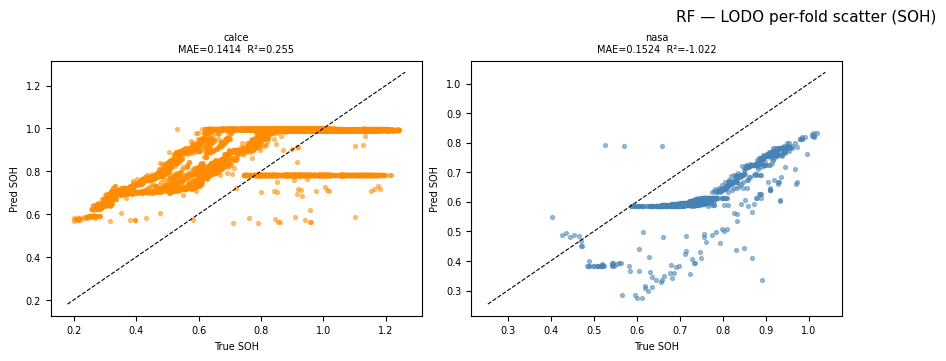

  Saved: c:\dev\ml-project\results\extended_tier1\04_bigru_lodo_per_fold.png


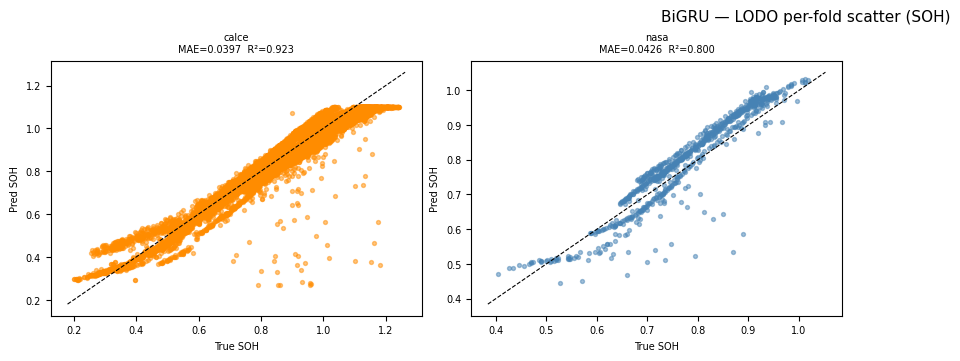

  Saved: c:\dev\ml-project\results\extended_tier1\04_cnnlstm_lodo_per_fold.png


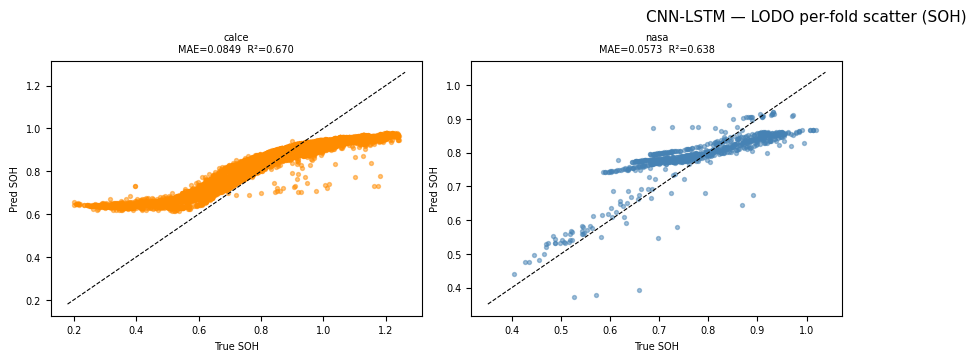

  Saved: c:\dev\ml-project\results\extended_tier1\04_transformer_lodo_per_fold.png


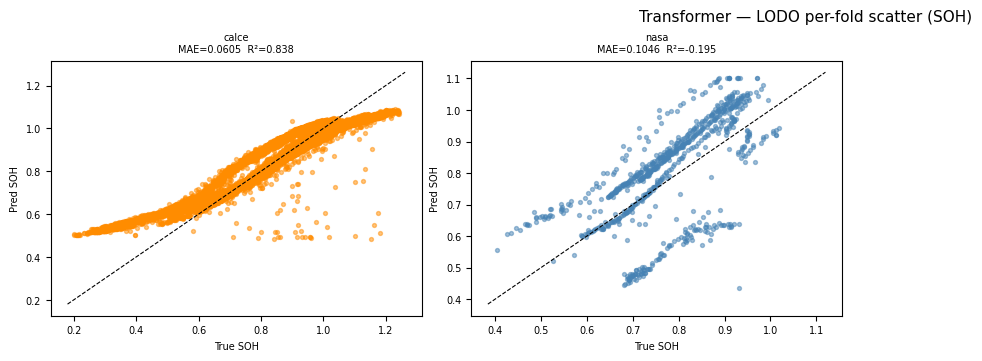

  Saved: c:\dev\ml-project\results\extended_tier1\04_attngru_lodo_per_fold.png


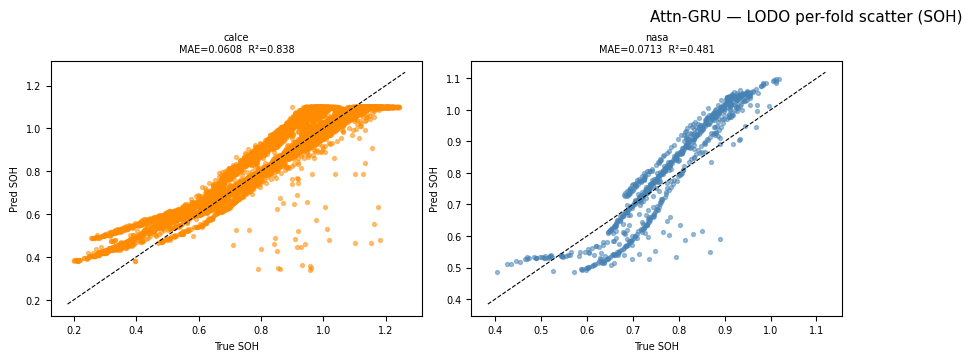

  Saved: c:\dev\ml-project\results\extended_tier1\04_grubase3_lodo_per_fold.png


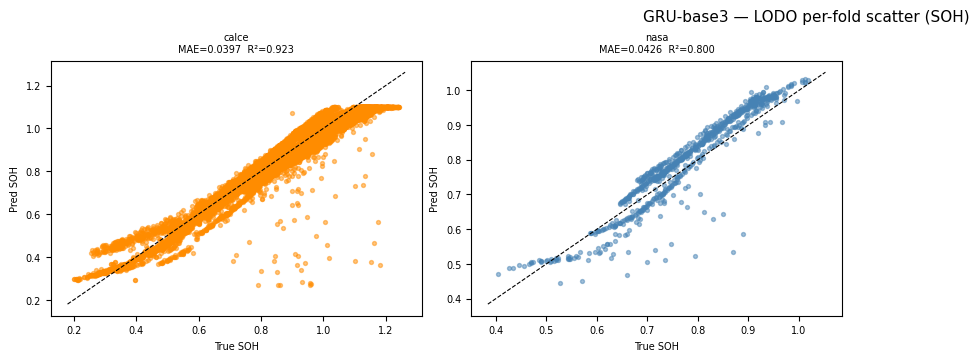

  Saved: c:\dev\ml-project\results\extended_tier1\04_gruinv4_lodo_per_fold.png


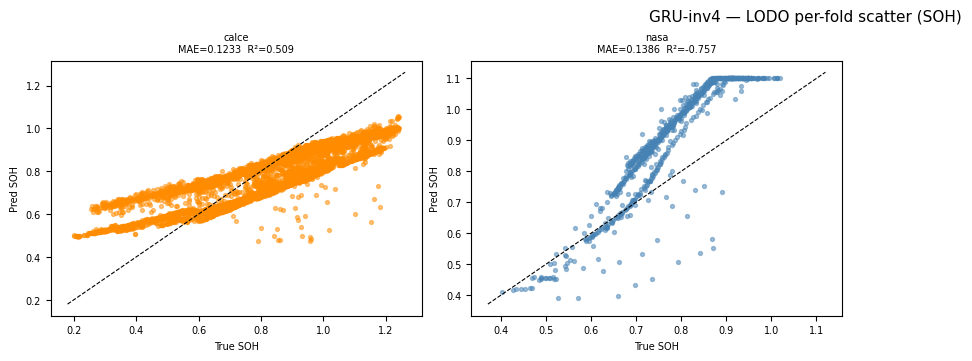

  Saved: c:\dev\ml-project\results\extended_tier1\04_grufull5_lodo_per_fold.png


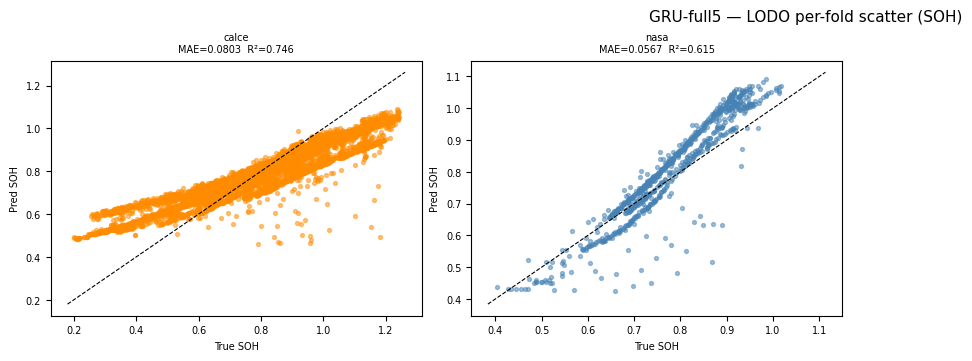

  Saved: c:\dev\ml-project\results\extended_tier1\04_gruinv3+aug_lodo_per_fold.png


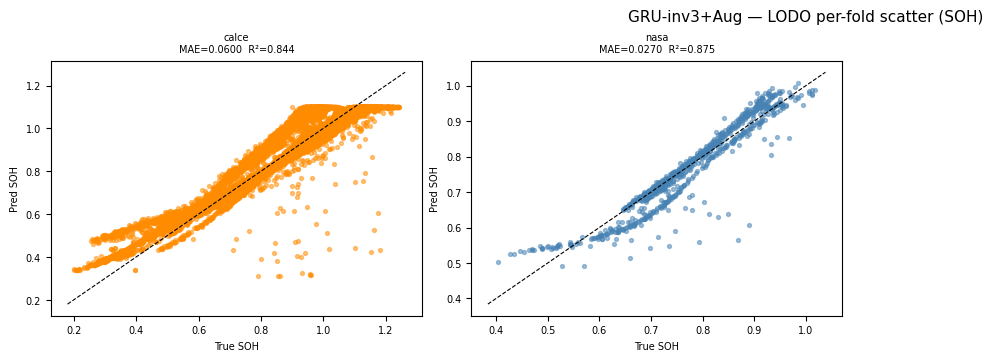

  Saved: c:\dev\ml-project\results\extended_tier1\04_gruinv3+coral_lodo_per_fold.png


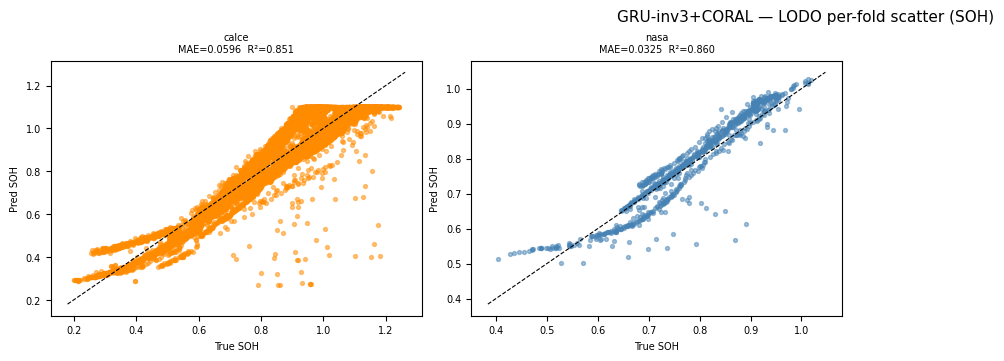

  Saved: c:\dev\ml-project\results\extended_tier1\04_gruinv3+dann_lodo_per_fold.png


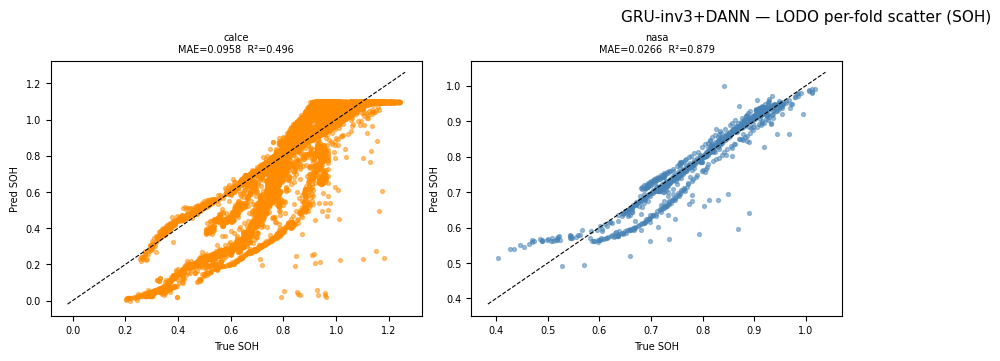

In [58]:
ARM_ORDER_LODO = [
    # -- Reference architectures (base3 channels) --
    ("RF",             res_rf_lodo,             agg_rf_lodo),
    ("BiGRU",          res_gru_lodo,            agg_gru_lodo),
    ("CNN-LSTM",       res_cnnlstm_lodo,        agg_cnnlstm_lodo),
    ("Transformer",    res_transformer_lodo,    agg_transformer_lodo),
    ("Attn-GRU",       res_attngru_lodo,        agg_attngru_lodo),
    # -- Protocol-invariant representation experiments --
    ("GRU-inv4",       res_gru_inv4_lodo,       agg_gru_inv4_lodo),
    ("GRU-full5",      res_gru_full5_lodo,      agg_gru_full5_lodo),
    ("GRU-inv3+Aug",   res_gru_inv3_aug_lodo,   agg_gru_inv3_aug_lodo),
    ("GRU-inv3+CORAL", res_gru_inv3_coral_lodo, agg_gru_inv3_coral_lodo),
    ("GRU-inv3+DANN",  res_gru_inv3_dann_lodo,  agg_gru_inv3_dann_lodo),
]

lodo_rows = []
for arm, res, _ in ARM_ORDER_LODO:
    for fold in res:
        m = fold["metrics"]
        held_ds = ",".join(fold.get("held_group") or [])
        lodo_rows.append({
            "Model":        arm,
            "Held dataset": held_ds,
            "MAE":          round(m["mae"],      4),
            "RMSE":         round(m["rmse"],     4),
            "R\u00b2":      round(m["r2"],       4),
            "Skill":        round(m["skill"],    4),
            "Spearman":     round(m["spearman"], 4),
            "n":            m["n"],
        })

df_lodo = pd.DataFrame(lodo_rows)
print("=== Leave-One-Dataset-Out results ===")
display(df_lodo.pivot_table(
    index="Held dataset", columns="Model",
    values=["MAE", "RMSE", "R\u00b2", "Skill"], sort=False,
).round(4))

df_lodo.to_csv(RESULTS / "04_comparison_lodo_metrics.csv", index=False)
print(f"Saved: {RESULTS / '04_comparison_lodo_metrics.csv'}")

for arm, res, _ in ARM_ORDER_LODO:
    vgx.per_fold_scatter_ext(
        res,
        f"{arm} — LODO per-fold scatter (SOH)",
        save_path=RESULTS / f"04_{arm.lower().replace('-', '').replace(' ', '_')}_lodo_per_fold.png",
    )

## Conclusion

### Results summary

**GroupKFold-6 (in-distribution)**

Transformer is the strongest in-distribution model (MAE 0.0332, R² 0.846, Spearman 0.96),
but also the most volatile (std 0.026; collapses to MAE 0.088 on the NASA-RW fold).
BiGRU, Attn-GRU, and CNN-LSTM all score ~0.037–0.038 — statistically indistinguishable
on a single seed.

**Leave-One-Dataset-Out (LODO) transfer**

BiGRU is the most balanced transferer (aggregate MAE 0.041, calce 0.040 / nasa 0.043).
Transformer collapses on transfer-to-NASA (MAE 0.105, R² −0.20).
CNN-LSTM transfers moderately (0.071).

---

### Three findings

**1. Representation hypothesis rejected.**
Replacing `t_elapsed` with Q_frac+dQ/dV (`inv4`, `full5`) was expected to improve
transfer because Q and dQ/dV are rate-invariant in the physics sense.
Instead, `GRU-inv4` was *worse* in-distribution (MAE 0.047) and suffered dramatically
on NASA-CTRL (R² −1.34). The features introduce a *different* fingerprint: absolute
Q(V) curve shape differs between CALCE and NASA chemistries (different electrode
loadings, voltage windows), so the model still encodes source-domain identity.
**Adding channels did not help; the representation hypothesis was refuted by the data.**

**2. Rate-warp augmentation is the effective lever.**
`GRU-inv3+Aug` (BiGRU + rate_warp ±25%) achieves the **best NASA transfer of all models
tested** (LODO nasa MAE 0.027) and the most stable cross-fold performance (GKF-6 std 0.009).
It trades a small CALCE regression (LODO calce 0.060 vs 0.040 for plain BiGRU) for a
large NASA gain. Augmentation works where explicit invariant features did not: instead of
designing out the rate fingerprint, it teaches the model to ignore it.

**3. CORAL and DANN gave no gain.**
Both underperformed plain BiGRU on aggregate LODO transfer (CORAL 0.046, DANN 0.061).
DANN was additionally unstable (CALCE MAE 0.096). Domain-adaptation objectives added
architectural and training complexity without measurable benefit at this dataset scale.

---

### Best model so far

**BiGRU (h=47) + rate-warp augmentation** — robust across protocols, simple (~15k params),
lowest NASA transfer error, smallest cross-fold variance.

*Note: fold aggregate weights each fold equally regardless of dataset size; NASA folds
(744 samples) carry the same weight as CALCE folds (~10k samples).*